<a href="https://colab.research.google.com/github/ShaguftaKhan703/CS273_Project01_Group5/blob/main/group5_dataset1_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### **STEP 1: Data Loading & Cleaning**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

In [3]:
# Load the dataset as a Pandas DataFrames
emo_sounds_df = pd.read_csv("/content/drive/Shareddrives/CS 273: Project 1 - Group # 5/group5_raw_data/EmoSounds-3.csv")

# Drop the unwanted columns in the datasets
emo_sounds_df.drop(columns=['dataset', 'fnames', 'genre', 'splits', 'vocals'], inplace=True)

In [4]:
# Clean the EmoSounds dataset

# Handle the NaN values
d1_null_count = emo_sounds_df.isnull().sum()
d1_null_values = d1_null_count[d1_null_count > 0]
d1_columns = d1_null_values.index.values

emo_sounds_df.dropna(subset=d1_columns, how='any', inplace=True)

# Drop the duplicate rows
emo_sounds_df.drop_duplicates(subset=None, keep='first', inplace=True)

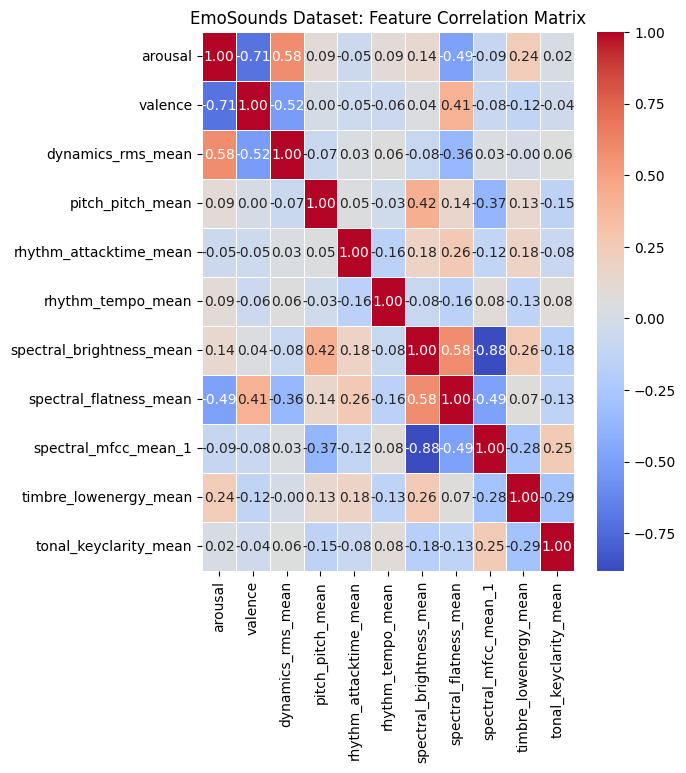

In [5]:
# Visualize EmoSounds dataset using randomly selected features
matrix1_subset = ['arousal',
          'valence',
          'dynamics_rms_mean',
          'pitch_pitch_mean',
          'rhythm_attacktime_mean',
          'rhythm_tempo_mean',
          'spectral_brightness_mean',
          'spectral_flatness_mean',
          'spectral_mfcc_mean_1',
          'timbre_lowenergy_mean',
          'tonal_keyclarity_mean']

matrix1_subset = emo_sounds_df[matrix1_subset].corr()

plt.figure(figsize=(6, 7))
sns.heatmap(matrix1_subset, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("EmoSounds Dataset: Feature Correlation Matrix")
plt.savefig("/content/drive/Shareddrives/CS 273: Project 1 - Group # 5/group5_figures/figure1", bbox_inches="tight")


In [6]:
# Preprocess the EmoSounds dataset
# Additional preprocessing will be done in later cells

# Shuffle the dataset
dataset_1_df = emo_sounds_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [7]:
# Save the preprocessed datasets as CSV files
dataset_1_df.to_csv("/content/drive/Shareddrives/CS 273: Project 1 - Group # 5/group5_preprocessed_data/clean_emo_sounds.csv")

#### **STEP 2: Data Splitting**

In [8]:
# Load the preprocessed data
df = pd.read_csv("/content/drive/Shareddrives/CS 273: Project 1 - Group # 5/group5_preprocessed_data/clean_emo_sounds.csv", index_col=0)

In [9]:
# Step 0: Hold out the test set once (80:20 ratio)

X = df.drop(columns=['arousal', 'valence']) # feature columns
y = df[['arousal', 'valence']] # target columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Split Information: \n")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Split Information: 

X_train shape: (480, 68)
y_train shape: (480, 2)
X_test shape: (120, 68)
y_test shape: (120, 2)


#### **STEP 3: Model Training**

In [10]:
# Create function for feature selection - select rows where the abs(correlation coefficient) > 0.4
# All models will make use of this same feature selection technique

corr_matrix = pd.concat([X_train, y_train], axis=1).corr()
selected_df = corr_matrix[(corr_matrix['arousal'].abs() > 0.4) | (corr_matrix['valence'].abs() > 0.4)]
selected_rows = selected_df.index[:-2]

In [11]:
# Create functions for 5-fold CV and data normalization

# This function normalizes the features (range: 0 - 1)
def create_pipeline(model):
  pipeline = Pipeline([
      ('scaler', MinMaxScaler()),
      ('model', model)
  ])

  return pipeline

# This function implements 5-fold Cross Validation
def perform_k_fold(pipeline, feature_selection=False, rows=None):
  x_train = X_train
  if (feature_selection):
    x_train = X_train[rows]

  # Perform 5-fold Cross Validation
  k = 5
  kf = KFold(n_splits=k, shuffle=True, random_state=42)

  cv_scores = cross_val_score(pipeline, x_train, y_train, cv=kf, scoring='neg_mean_squared_error')
  avg_cv_score = round(np.mean(cv_scores), 4)

  return avg_cv_score

In [12]:
# Model 1: Linear Regression

# Train the model prior to feature selection
lr = LinearRegression()
lr_pipeline = create_pipeline(lr)
lr_avg_cv_score = perform_k_fold(lr_pipeline)

lr_pipeline.fit(X_train, y_train)
lr_initial_train_pred = lr_pipeline.predict(X_train)
lr_train_mse = mean_squared_error(y_train, lr_initial_train_pred)

print("Linear Regression Metrics (prior to feature selection)")
print(f"Average CV score: {lr_avg_cv_score:.4f}")
print(f"Train set MSE: {lr_train_mse:.4f}")
print()

# Tune Hyperparameter 1: n_jobs
lr_optimal_cv_score = float('-inf')
n_jobs_values = [1, 5, 10]
optimal_n_jobs = n_jobs_values[0]

for val in n_jobs_values:
  lr_model = LinearRegression(n_jobs=val)
  curr_lr_pipeline = create_pipeline(lr_model)
  lr_cv_score = perform_k_fold(curr_lr_pipeline, True, selected_rows)

  if (lr_cv_score > lr_optimal_cv_score):
    lr_optimal_cv_score = lr_cv_score
    optimal_n_jobs = val

# Retrain the model again + Evaluate once on test set
final_lr = LinearRegression(n_jobs=optimal_n_jobs)
final_lr_pipeline = create_pipeline(final_lr)

final_lr_pipeline.fit(X_train[selected_rows], y_train)

lr_train_pred = final_lr_pipeline.predict(X_train[selected_rows])
lr_y_pred = final_lr_pipeline.predict(X_test[selected_rows])

lr_final_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_final_test_mse = mean_squared_error(y_test, lr_y_pred)

print("Linear Regression Metrics (after feature selection)")
print(f"Average CV score: {lr_optimal_cv_score:.4f}")
print(f"Train set MSE: {lr_final_train_mse:.4f}")
print(f"Test set MSE: {lr_final_test_mse:.4f}")
print(f"Optimal number of jobs: {optimal_n_jobs}")

Linear Regression Metrics (prior to feature selection)
Average CV score: -0.1408
Train set MSE: 0.0853

Linear Regression Metrics (after feature selection)
Average CV score: -0.1740
Train set MSE: 0.1546
Test set MSE: 0.1858
Optimal number of jobs: 1


In [13]:
# Model 2 (EmoSounds dataset): Random Forest Regression

# Train the model prior to feature selection
rf = RandomForestRegressor(random_state=42)
rf_pipeline = create_pipeline(rf)
rf_avg_cv_score = perform_k_fold(rf_pipeline)

rf_pipeline.fit(X_train, y_train)
rf_initial_train_pred = rf_pipeline.predict(X_train)
rf_train_mse = mean_squared_error(y_train, rf_initial_train_pred)

print("Random Forest Regression Metrics (prior to feature selection and hyperparameter tuning)")
print(f"Average CV score: {rf_avg_cv_score:.4f}")
print(f"Train set MSE: {rf_train_mse:.4f}")
print()

# Tune hyperparameters
rf_optimal_cv_score = float('-inf')

# Hyperparameter 1: max_depth
max_depths = [5, 10, 15, 30]
optimal_max_depth = max_depths[0]

for val in max_depths:
  rf_model = RandomForestRegressor(max_depth=val, random_state=42)
  curr_rf_pipeline = create_pipeline(rf_model)
  rf_cv_score = perform_k_fold(curr_rf_pipeline, True, selected_rows)

  if (rf_cv_score > rf_optimal_cv_score):
    rf_optimal_cv_score = rf_cv_score
    optimal_max_depth = val


# Hyperparameter 2: max_features
max_features = ["sqrt", "log2", 0.25, 0.5]
optimal_max_features = max_features[0]

for val in max_features:
  rf_model = RandomForestRegressor(max_depth=optimal_max_depth, max_features=val, random_state=42)
  curr_rf_pipeline = create_pipeline(rf_model)
  rf_cv_score = perform_k_fold(curr_rf_pipeline, True, selected_rows)

  if (rf_cv_score > rf_optimal_cv_score):
    rf_optimal_cv_score = rf_cv_score
    optimal_max_features = val

# Retrain model and evaluate on test set
final_rf = RandomForestRegressor(max_depth=optimal_max_depth, max_features=optimal_max_features, random_state=42)

final_rf.fit(X_train[selected_rows], y_train)

rf_train_pred = final_rf.predict(X_train[selected_rows])
rf_y_pred = final_rf.predict(X_test[selected_rows])

rf_final_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_final_test_mse = mean_squared_error(y_test, rf_y_pred)


print("Random Forest Metrics (after feature selection and hyperparameter tuning)")
print(f"Average CV score: {rf_optimal_cv_score:.4f}")
print(f"Train set MSE: {rf_final_train_mse:.4f}")
print(f"Test set MSE: {rf_final_test_mse:.4f}")
print(f"Optimal max depth of trees: {optimal_max_depth}")
print(f"Optimal max features at each split: {optimal_max_features}")

Random Forest Regression Metrics (prior to feature selection and hyperparameter tuning)
Average CV score: -0.0984
Train set MSE: 0.0136

Random Forest Metrics (after feature selection and hyperparameter tuning)
Average CV score: -0.1235
Train set MSE: 0.0170
Test set MSE: 0.1351
Optimal max depth of trees: 30
Optimal max features at each split: sqrt


In [14]:
# Model 3 (EmoSounds dataset): MLPRegressor

# Train the model prior to feature selection
mlp = MLPRegressor(activation='relu', random_state=42)
mlp_pipeline = create_pipeline(mlp)
mlp_avg_cv_score = perform_k_fold(mlp_pipeline)

mlp_pipeline.fit(X_train, y_train)
mlp_initial_train_pred = mlp_pipeline.predict(X_train)
mlp_train_mse = mean_squared_error(y_train, mlp_initial_train_pred)

print("MLP Regression Metrics (prior to feature selection and hyperparameter tuning)")
print(f"Average CV score: {mlp_avg_cv_score :.4f}")
print(f"Train set MSE: {mlp_train_mse:.4f}")
print()

# Tune hyperparameters
mlp_optimal_cv_score = float('-inf')

# Hyperparameter 1: hidden_layer_sizes
sizes = [(16, ), (16, 8), (32, 16), (64, 32)]
optimal_size = sizes[0]

for val in sizes:
  mlp_model = MLPRegressor(hidden_layer_sizes=val, activation='relu', random_state=42)
  curr_mlp_pipeline = create_pipeline(mlp_model)
  mlp_cv_score = perform_k_fold(curr_mlp_pipeline, True, selected_rows)

  if (mlp_cv_score > mlp_optimal_cv_score):
    mlp_optimal_cv_score = mlp_cv_score
    optimal_size = val

# Hyperparameter 2: alpha
alpha_values = [0.0001, 0.001, 0.01, 0.1]
optimal_alpha = alpha_values[0]

for val in alpha_values:
  mlp_model = MLPRegressor(hidden_layer_sizes=optimal_size, alpha=val, activation='relu', random_state=42)
  curr_mlp_pipeline = create_pipeline(mlp_model)
  mlp_cv_score = perform_k_fold(curr_mlp_pipeline, True, selected_rows)

  if (mlp_cv_score > mlp_optimal_cv_score):
    mlp_optimal_cv_score = mlp_cv_score
    optimal_alpha = val


# Retrain model and evaluate on test set
final_mlp = MLPRegressor(hidden_layer_sizes=optimal_size, alpha=optimal_alpha, activation='relu', random_state=42)
final_mlp_pipeline = create_pipeline(final_mlp)

final_mlp_pipeline.fit(X_train[selected_rows], y_train)

mlp_train_pred = final_mlp_pipeline.predict(X_train[selected_rows])
mlp_y_pred = final_mlp_pipeline.predict(X_test[selected_rows])

mlp_final_train_mse = mean_squared_error(y_train, mlp_train_pred)
mlp_final_test_mse = mean_squared_error(y_test, mlp_y_pred)

print("MLP Regression Metrics (after feature selection and hyperparameter tuning)")
print(f"Average CV score: {mlp_optimal_cv_score:.4f}")
print(f"Train set MSE: {mlp_final_train_mse:.4f}")
print(f"Test set MSE: {mlp_final_test_mse:.4f}")
print(f"Optimal hidden layer size: {optimal_size}")
print(f"Optimal learning rate: {optimal_alpha}")

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptro

MLP Regression Metrics (prior to feature selection and hyperparameter tuning)
Average CV score: -0.1033
Train set MSE: 0.0517



/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptro

MLP Regression Metrics (after feature selection and hyperparameter tuning)
Average CV score: -0.1192
Train set MSE: 0.0995
Test set MSE: 0.1213
Optimal hidden layer size: (64, 32)
Optimal learning rate: 0.0001


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


##